# Week 8 — Image Compression

Digital Image Processing mini project: Driver Drowsiness Detection.
Amey Pawar (23108B0057), Sejal Andhale (23108B0049).

**Question this notebook answers:** an in-vehicle camera transmitting eye
crops to a fleet server has limited bandwidth. How far can a frame be
JPEG-compressed before the Week-6 eye-state classifier
(`src.classify.predict_eye_state`, RBF-SVM on HOG+LBP, test accuracy
**0.8965**, AUC 0.9621) degrades?

All compression code lives in `src/compression.py` (imported, not
reimplemented per cell). The Week-5 DCT energy-compaction functions
(`src.transforms.dct2`, `dct_energy_compaction`) are reused directly, not
rewritten.

1. **Visual quality ladder** — same eye crop at descending JPEG qualities.
2. **PSNR/SSIM vs quality** curves.
3. **The headline rate-accuracy curve** — the practical payoff.
4. **Manual block-DCT + quantization codec vs library JPEG**, matched quality.
5. **8x8 DCT coefficient heatmap** + the quantization table used.
6. **Energy-compaction / top-k reconstruction** (Week-5 functions reused).
7. Written conclusion — recommended operating point.


In [1]:
import sys
import csv
import random
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.dataset import load_manifest
from src.preprocess import preprocess_pipeline, DEFAULT_CONFIG
from src.transforms import dct2, dct_energy_compaction
from src.compression import (
    QUALITY_LEVELS, STD_LUMA_QTABLE,
    jpeg_encode_decode, jpeg_quality_sweep, bits_per_pixel, image_quality_metrics,
    scale_quant_table, manual_dct_reconstruct, manual_bit_estimate,
    reconstruct_from_topk, topk_reconstruction_sweep,
    load_test_split, rate_accuracy_sweep, find_knee_point, bandwidth_kb_per_s,
)

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

BASELINE_ACC = 0.8965  # Week-6 committed test accuracy, RBF-SVM on HOG+LBP

MANIFEST_PATH = REPO_ROOT / "data" / "samples" / "manifest.csv"
samples = load_manifest(MANIFEST_PATH)
print(f"{len(samples)} curated samples (used only for illustrative single-image figures)")

test_rows = load_test_split()
print(f"{len(test_rows)} test-split rows (used for every measured curve/table below)")


40 curated samples (used only for illustrative single-image figures)
1140 test-split rows (used for every measured curve/table below)


## 1. Visual quality ladder

One representative raw eye crop (native MRL resolution, **not** the
64x64 `preprocess_pipeline` output — this is the frame as a camera would
actually capture and transmit), JPEG-compressed at descending quality.
Displayed 4x nearest-neighbour-upscaled purely so blocking artifacts are
visible on screen; all measurements elsewhere in this notebook are taken
on the native-resolution image, never the upscaled display copy.


demo crop native shape: (147, 147)


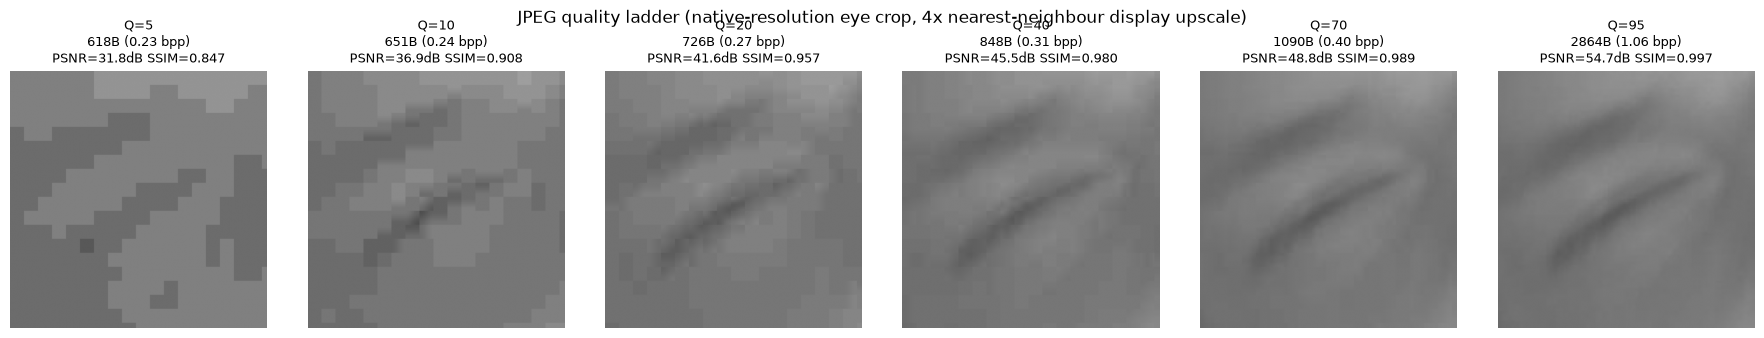

In [2]:
demo_sample = next(s for s in samples if not s.is_open)
demo_raw = cv2.imread(str(demo_sample.path), cv2.IMREAD_GRAYSCALE)
print("demo crop native shape:", demo_raw.shape)

ladder_qualities = [5, 10, 20, 40, 70, 95]
fig, axes = plt.subplots(1, len(ladder_qualities), figsize=(3 * len(ladder_qualities), 3.4))

for ax, q in zip(axes, ladder_qualities):
    decoded, n_bytes = jpeg_encode_decode(demo_raw, q)
    bpp = bits_per_pixel(n_bytes, demo_raw.shape)
    metrics = image_quality_metrics(demo_raw, decoded)
    big = cv2.resize(decoded, None, fx=4, fy=4, interpolation=cv2.INTER_NEAREST)
    ax.imshow(big, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Q={q}\n{n_bytes}B ({bpp:.2f} bpp)\nPSNR={metrics['psnr']:.1f}dB SSIM={metrics['ssim']:.3f}", fontsize=9)
    ax.axis("off")

fig.suptitle("JPEG quality ladder (native-resolution eye crop, 4x nearest-neighbour display upscale)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week8_quality_ladder.png", dpi=150, bbox_inches="tight")
plt.show()


## 2 & 3. Headline experiment: rate-accuracy sweep over the full test split

Every one of the 1,140 test-split raw eye crops, JPEG-compressed and
decoded at each quality in `QUALITY_LEVELS`, run through
`predict_eye_state` (which internally applies `preprocess_pipeline`,
exactly mirroring the real capture -> compress -> transmit -> decode ->
resize/enhance -> classify pipeline), scored against ground truth. PSNR
and SSIM (vs the original raw crop) are aggregated in the same pass — no
separate compute needed for the PSNR/SSIM-vs-quality curves below.


In [3]:
t0 = time.time()
rate_results = rate_accuracy_sweep(test_rows, qualities=QUALITY_LEVELS)
print(f"\ntotal sweep wall time: {time.time() - t0:.1f}s")


  baseline (uncompressed): accuracy=0.8965


  quality=  5 accuracy=0.6149 mean_bpp=0.419 mean_KB=0.471 psnr=31.24 ssim=0.7974 (10.6s)


  quality= 10 accuracy=0.7667 mean_bpp=0.443 mean_KB=0.502 psnr=35.52 ssim=0.8727 (10.8s)


  quality= 15 accuracy=0.8123 mean_bpp=0.468 mean_KB=0.533 psnr=37.77 ssim=0.9102 (10.8s)


  quality= 20 accuracy=0.8456 mean_bpp=0.491 mean_KB=0.563 psnr=39.25 ssim=0.9301 (10.8s)


...

  quality= 60 accuracy=0.8930 mean_bpp=0.678 mean_KB=0.811 psnr=43.76 ssim=0.9689 (10.7s)


  quality= 70 accuracy=0.8956 mean_bpp=0.771 mean_KB=0.934 psnr=44.75 ssim=0.9744 (10.8s)


  quality= 80 accuracy=0.9009 mean_bpp=0.930 mean_KB=1.142 psnr=46.02 ssim=0.9801 (10.8s)


  quality= 90 accuracy=0.9088 mean_bpp=1.325 mean_KB=1.651 psnr=48.17 ssim=0.9874 (10.7s)


  quality= 95 accuracy=0.9035 mean_bpp=1.869 mean_KB=2.350 psnr=50.21 ssim=0.9920 (10.6s)

total sweep wall time: 150.3s


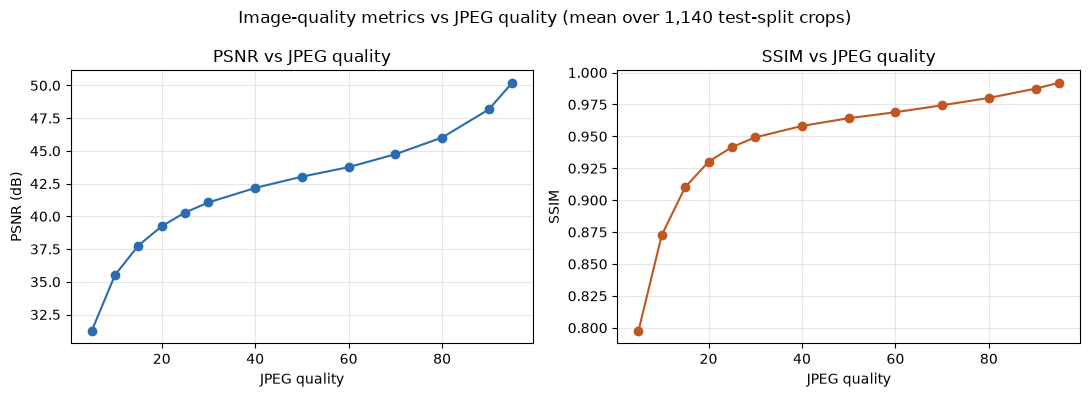

In [4]:
quality_points = [r for r in rate_results if r.quality is not None]
qualities_arr = np.array([r.quality for r in quality_points])
psnr_arr = np.array([r.psnr_mean for r in quality_points])
ssim_arr = np.array([r.ssim_mean for r in quality_points])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(qualities_arr, psnr_arr, "o-", color="#2b6cb0")
axes[0].set_xlabel("JPEG quality"); axes[0].set_ylabel("PSNR (dB)"); axes[0].set_title("PSNR vs JPEG quality")
axes[0].grid(alpha=0.3)

axes[1].plot(qualities_arr, ssim_arr, "o-", color="#c05621")
axes[1].set_xlabel("JPEG quality"); axes[1].set_ylabel("SSIM"); axes[1].set_title("SSIM vs JPEG quality")
axes[1].grid(alpha=0.3)

fig.suptitle("Image-quality metrics vs JPEG quality (mean over 1,140 test-split crops)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week8_psnr_ssim_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()


### The rate-accuracy curve — headline figure

Bits-per-pixel on x, classification accuracy on y, uncompressed 0.8965
baseline as a reference line. Knee point: the **lowest-bitrate** quality
level whose accuracy stays within 1% absolute of baseline.


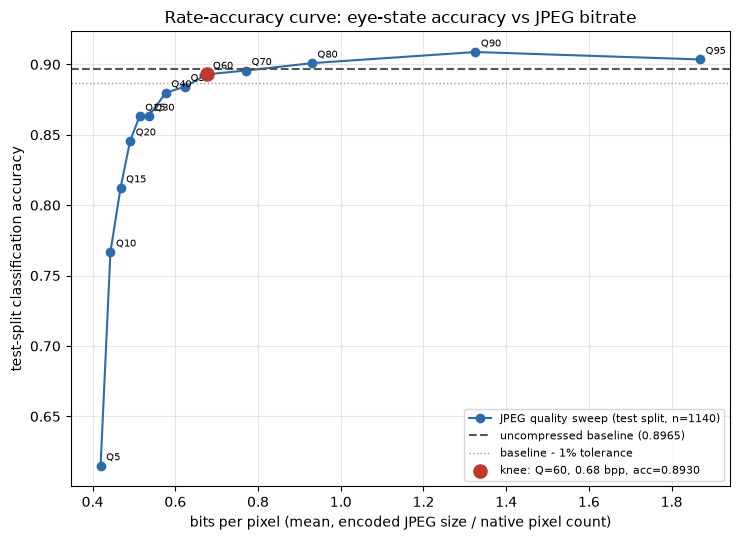

knee point: quality=60  bpp=0.678  KB/frame=0.811  accuracy=0.8930  psnr=43.76dB  ssim=0.9689
bandwidth @ 30 fps: 24.3 KB/s (194.7 kbit/s)


In [5]:
bpp_arr = np.array([r.mean_bpp for r in quality_points])
kb_arr = np.array([r.mean_kb for r in quality_points])
acc_arr = np.array([r.accuracy for r in quality_points])

knee = find_knee_point(rate_results, tolerance=0.01)
bw_kbps = bandwidth_kb_per_s(knee.mean_kb, fps=30.0)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(bpp_arr, acc_arr, "o-", color="#2b6cb0", label="JPEG quality sweep (test split, n=1140)")
ax.axhline(BASELINE_ACC, color="#555", linestyle="--", label=f"uncompressed baseline ({BASELINE_ACC:.4f})")
ax.axhline(BASELINE_ACC - 0.01, color="#999", linestyle=":", linewidth=1, label="baseline - 1% tolerance")
ax.scatter([knee.mean_bpp], [knee.accuracy], color="#c0392b", s=90, zorder=5,
           label=f"knee: Q={knee.quality}, {knee.mean_bpp:.2f} bpp, acc={knee.accuracy:.4f}")

for r in quality_points:
    ax.annotate(f"Q{r.quality}", (r.mean_bpp, r.accuracy), textcoords="offset points", xytext=(4, 4), fontsize=7)

ax.set_xlabel("bits per pixel (mean, encoded JPEG size / native pixel count)")
ax.set_ylabel("test-split classification accuracy")
ax.set_title("Rate-accuracy curve: eye-state accuracy vs JPEG bitrate")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week8_rate_accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"knee point: quality={knee.quality}  bpp={knee.mean_bpp:.3f}  KB/frame={knee.mean_kb:.3f}  "
      f"accuracy={knee.accuracy:.4f}  psnr={knee.psnr_mean:.2f}dB  ssim={knee.ssim_mean:.4f}")
print(f"bandwidth @ 30 fps: {bw_kbps:.1f} KB/s ({bw_kbps * 8:.1f} kbit/s)")


In [6]:
print(f"{'quality':>7} | {'accuracy':>8} | {'bpp':>6} | {'KB/frame':>8} | {'PSNR(dB)':>8} | {'SSIM':>6}")
print("-" * 62)
base = next(r for r in rate_results if r.quality is None)
print(f"{'raw':>7} | {base.accuracy:8.4f} | {'--':>6} | {'--':>8} | {'inf':>8} | {'1.0':>6}")
for r in quality_points:
    print(f"{r.quality:7d} | {r.accuracy:8.4f} | {r.mean_bpp:6.3f} | {r.mean_kb:8.3f} | {r.psnr_mean:8.2f} | {r.ssim_mean:6.4f}")


quality | accuracy |    bpp | KB/frame | PSNR(dB) |   SSIM
--------------------------------------------------------------
    raw |   0.8965 |     -- |       -- |      inf |    1.0
      5 |   0.6149 |  0.419 |    0.471 |    31.24 | 0.7974
     10 |   0.7667 |  0.443 |    0.502 |    35.52 | 0.8727
     15 |   0.8123 |  0.468 |    0.533 |    37.77 | 0.9102
     20 |   0.8456 |  0.491 |    0.563 |    39.25 | 0.9301
     25 |   0.8632 |  0.514 |    0.592 |    40.29 | 0.9416
     30 |   0.8632 |  0.535 |    0.621 |    41.06 | 0.9492
     40 |   0.8798 |  0.577 |    0.676 |    42.17 | 0.9581
     50 |   0.8842 |  0.623 |    0.739 |    43.03 | 0.9642
     60 |   0.8930 |  0.678 |    0.811 |    43.76 | 0.9689
     70 |   0.8956 |  0.771 |    0.934 |    44.75 | 0.9744
     80 |   0.9009 |  0.930 |    1.142 |    46.02 | 0.9801
     90 |   0.9088 |  1.325 |    1.651 |    48.17 | 0.9874
     95 |   0.9035 |  1.869 |    2.350 |    50.21 | 0.9920


## 4. Manual block-wise DCT + quantization codec vs library JPEG

`src.compression.manual_dct_reconstruct` implements JPEG's actual lossy
core from scratch: level-shift, per-8x8-block `src.transforms.dct2`,
divide-and-round by a quality-scaled standard luminance quantization
table, dequantize, inverse DCT, level-shift back. No entropy coding
stage, so its rate is a **zeroth-order Shannon-entropy estimate**
(`manual_bit_estimate`), not a measured byte count like library JPEG's —
labelled as such below.


In [7]:
random.seed(42)
compare_sample = random.sample(test_rows, 150)
compare_imgs = [cv2.imread(str(REPO_ROOT / r["source_relpath"]), cv2.IMREAD_GRAYSCALE) for r in compare_sample]
compare_qualities = [10, 30, 50, 70, 90]

rows_table = []
for q in compare_qualities:
    lib_psnr, lib_ssim, lib_bpp = [], [], []
    man_psnr, man_ssim, man_bpp = [], [], []
    for img in compare_imgs:
        dec, nb = jpeg_encode_decode(img, q)
        m = image_quality_metrics(img, dec)
        lib_psnr.append(m["psnr"]); lib_ssim.append(m["ssim"]); lib_bpp.append(bits_per_pixel(nb, img.shape))

        recon = manual_dct_reconstruct(img, q)
        m2 = image_quality_metrics(img, recon)
        man_psnr.append(m2["psnr"]); man_ssim.append(m2["ssim"]); man_bpp.append(manual_bit_estimate(img, q))

    rows_table.append(dict(
        quality=q,
        lib_psnr=np.mean(lib_psnr), lib_ssim=np.mean(lib_ssim), lib_bpp=np.mean(lib_bpp),
        man_psnr=np.mean(man_psnr), man_ssim=np.mean(man_ssim), man_bpp=np.mean(man_bpp),
    ))

print(f"{'Q':>4} | {'lib PSNR':>9} | {'man PSNR':>9} | {'lib SSIM':>9} | {'man SSIM':>9} | {'lib bpp':>8} | {'man bpp*':>8}")
print("-" * 74)
for r in rows_table:
    print(f"{r['quality']:4d} | {r['lib_psnr']:9.2f} | {r['man_psnr']:9.2f} | {r['lib_ssim']:9.4f} | "
          f"{r['man_ssim']:9.4f} | {r['lib_bpp']:8.3f} | {r['man_bpp']:8.3f}")
print("\n*manual bpp is a zeroth-order entropy estimate over quantized DCT coefficients, not a measured byte count.")


   Q |  lib PSNR |  man PSNR |  lib SSIM |  man SSIM |  lib bpp | man bpp*
--------------------------------------------------------------------------
  10 |     35.56 |     35.55 |    0.8744 |    0.8745 |    0.459 |    0.208
  30 |     41.18 |     40.96 |    0.9507 |    0.9507 |    0.551 |    0.387
  50 |     43.18 |     42.85 |    0.9655 |    0.9653 |    0.637 |    0.522
  70 |     44.88 |     44.35 |    0.9751 |    0.9751 |    0.781 |    0.720
  90 |     48.29 |     47.18 |    0.9877 |    0.9876 |    1.332 |    1.387

*manual bpp is a zeroth-order entropy estimate over quantized DCT coefficients, not a measured byte count.


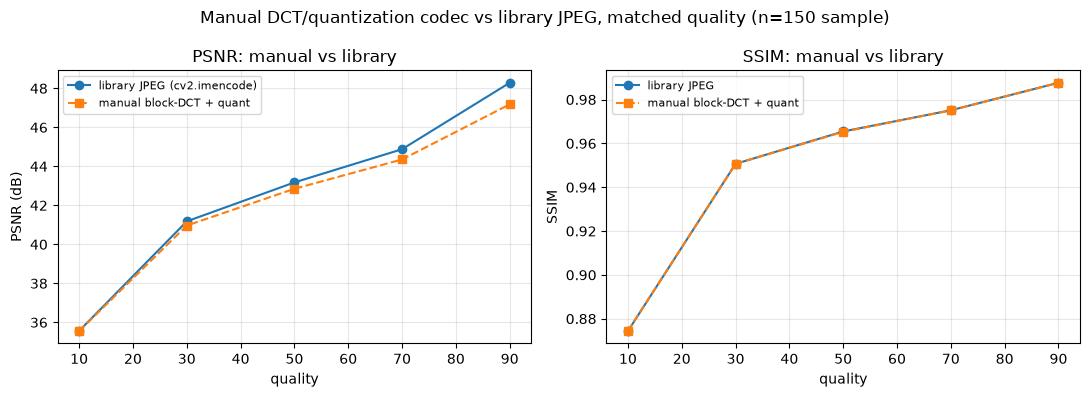

In [8]:
quals = [r["quality"] for r in rows_table]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(quals, [r["lib_psnr"] for r in rows_table], "o-", label="library JPEG (cv2.imencode)")
axes[0].plot(quals, [r["man_psnr"] for r in rows_table], "s--", label="manual block-DCT + quant")
axes[0].set_xlabel("quality"); axes[0].set_ylabel("PSNR (dB)"); axes[0].set_title("PSNR: manual vs library")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(quals, [r["lib_ssim"] for r in rows_table], "o-", label="library JPEG")
axes[1].plot(quals, [r["man_ssim"] for r in rows_table], "s--", label="manual block-DCT + quant")
axes[1].set_xlabel("quality"); axes[1].set_ylabel("SSIM"); axes[1].set_title("SSIM: manual vs library")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.suptitle(f"Manual DCT/quantization codec vs library JPEG, matched quality (n={len(compare_imgs)} sample)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week8_manual_vs_library_dct.png", dpi=150, bbox_inches="tight")
plt.show()


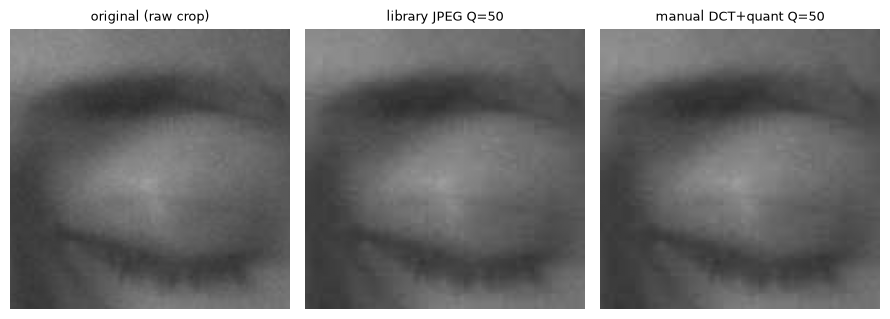

In [9]:
demo_img2 = compare_imgs[0]
q_demo = 50
lib_dec, lib_nb = jpeg_encode_decode(demo_img2, q_demo)
man_dec = manual_dct_reconstruct(demo_img2, q_demo)

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, im, title in zip(axes, [demo_img2, lib_dec, man_dec], ["original (raw crop)", f"library JPEG Q={q_demo}", f"manual DCT+quant Q={q_demo}"]):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255); ax.set_title(title, fontsize=9); ax.axis("off")
fig.tight_layout()
plt.show()


## 5. 8x8 DCT coefficient heatmap + quantization table

One 8x8 block's DCT coefficients (log-magnitude, low frequency top-left)
alongside the quality-scaled quantization table actually used by
`manual_dct_reconstruct` at the knee-point quality identified above.


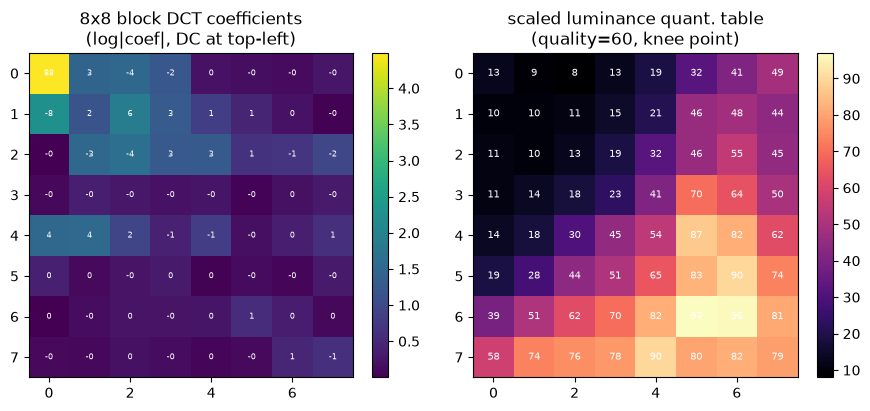

standard (quality=50) luminance quantization table:
 [[ 16.  11.  10.  16.  24.  40.  51.  61.]
 [ 12.  12.  14.  19.  26.  58.  60.  55.]
 [ 14.  13.  16.  24.  40.  57.  69.  56.]
 [ 14.  17.  22.  29.  51.  87.  80.  62.]
 [ 18.  22.  37.  56.  68. 109. 103.  77.]
 [ 24.  35.  55.  64.  81. 104. 113.  92.]
 [ 49.  64.  78.  87. 103. 121. 120. 101.]
 [ 72.  92.  95.  98. 112. 100. 103.  99.]]


In [10]:
block = (demo_img2[:8, :8].astype(np.float64) - 128.0)
coef = dct2(block)
log_mag = np.log1p(np.abs(coef))

qtable_knee = scale_quant_table(knee.quality)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(log_mag, cmap="viridis")
axes[0].set_title("8x8 block DCT coefficients\n(log|coef|, DC at top-left)")
for (yy, xx), val in np.ndenumerate(coef):
    axes[0].text(xx, yy, f"{val:.0f}", ha="center", va="center", color="white", fontsize=6)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(qtable_knee, cmap="magma")
axes[1].set_title(f"scaled luminance quant. table\n(quality={knee.quality}, knee point)")
for (yy, xx), val in np.ndenumerate(qtable_knee):
    axes[1].text(xx, yy, f"{val:.0f}", ha="center", va="center", color="white", fontsize=7)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "week8_dct_heatmap_qtable.png", dpi=150, bbox_inches="tight")
plt.show()

print("standard (quality=50) luminance quantization table:\n", STD_LUMA_QTABLE)


## 6. Energy compaction / top-k coefficient reconstruction

Reuses `src.transforms.dct2` / `dct_energy_compaction` (Week 5) directly.
Whole-image 2D DCT of the 64x64 preprocessed crop; keep only the
top-left k x k block of coefficients, zero everything else, inverse DCT.


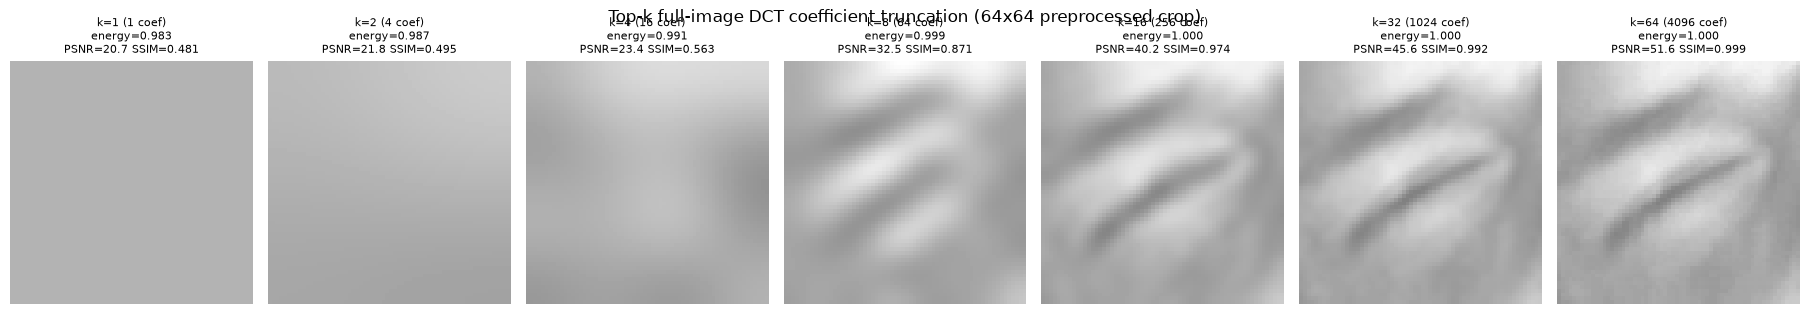

In [11]:
demo_enhanced = preprocess_pipeline(demo_raw, DEFAULT_CONFIG)
ks_ladder = [1, 2, 4, 8, 16, 32, 64]

fig, axes = plt.subplots(1, len(ks_ladder), figsize=(2.6 * len(ks_ladder), 3.2))
for ax, k in zip(axes, ks_ladder):
    recon = reconstruct_from_topk(demo_enhanced, k)
    frac = dct_energy_compaction(demo_enhanced, k)
    m = image_quality_metrics(demo_enhanced, recon)
    ax.imshow(recon, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"k={k} ({k*k} coef)\nenergy={frac:.3f}\nPSNR={m['psnr']:.1f} SSIM={m['ssim']:.3f}", fontsize=8)
    ax.axis("off")
fig.suptitle("Top-k full-image DCT coefficient truncation (64x64 preprocessed crop)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week8_energy_compaction_ladder.png", dpi=150, bbox_inches="tight")
plt.show()


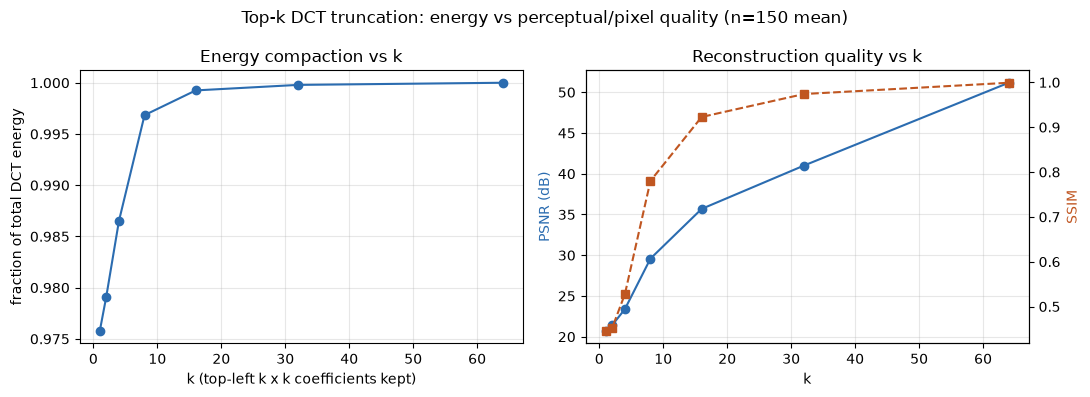

   k |  n_coef | energy_frac |    PSNR |    SSIM
   1 |       1 |      0.9758 |   20.69 |  0.4453
   2 |       4 |      0.9791 |   21.40 |  0.4519
   4 |      16 |      0.9865 |   23.38 |  0.5276
   8 |      64 |      0.9968 |   29.58 |  0.7802
  16 |     256 |      0.9993 |   35.68 |  0.9227
  32 |    1024 |      0.9998 |   41.00 |  0.9740
  64 |    4096 |      1.0000 |   51.17 |  0.9991

Note k=1 (DC-only, 1/4096 coefficients) already retains ~97% of total energy
yet SSIM is only ~0.44 -- energy fraction and perceptual quality diverge sharply
at the low end, since the discarded high-frequency coefficients carry almost no
energy but nearly all the fine structure SSIM is sensitive to.


In [12]:
random.seed(7)
topk_sample_rows = random.sample(test_rows, 150)
topk_sample_imgs = [preprocess_pipeline(cv2.imread(str(REPO_ROOT / r["source_relpath"]), cv2.IMREAD_GRAYSCALE), DEFAULT_CONFIG) for r in topk_sample_rows]

agg = {k: {"e": [], "p": [], "s": []} for k in ks_ladder}
for img in topk_sample_imgs:
    for tp in topk_reconstruction_sweep(img, ks_ladder):
        agg[tp.k]["e"].append(tp.energy_fraction)
        agg[tp.k]["p"].append(tp.psnr)
        agg[tp.k]["s"].append(tp.ssim)

e_mean = [np.mean(agg[k]["e"]) for k in ks_ladder]
p_mean = [np.mean(agg[k]["p"]) for k in ks_ladder]
s_mean = [np.mean(agg[k]["s"]) for k in ks_ladder]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax0 = axes[0]
ax0.plot(ks_ladder, e_mean, "o-", color="#2b6cb0", label="energy fraction retained")
ax0.set_xlabel("k (top-left k x k coefficients kept)"); ax0.set_ylabel("fraction of total DCT energy")
ax0.set_title("Energy compaction vs k")
ax0.grid(alpha=0.3)

ax1 = axes[1]
ax1.plot(ks_ladder, p_mean, "o-", color="#2b6cb0", label="PSNR (dB)")
ax1b = ax1.twinx()
ax1b.plot(ks_ladder, s_mean, "s--", color="#c05621", label="SSIM")
ax1.set_xlabel("k"); ax1.set_ylabel("PSNR (dB)", color="#2b6cb0"); ax1b.set_ylabel("SSIM", color="#c05621")
ax1.set_title("Reconstruction quality vs k")
ax1.grid(alpha=0.3)

fig.suptitle(f"Top-k DCT truncation: energy vs perceptual/pixel quality (n={len(topk_sample_imgs)} mean)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "week8_energy_compaction.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'k':>4} | {'n_coef':>7} | {'energy_frac':>11} | {'PSNR':>7} | {'SSIM':>7}")
for k, e, p, s in zip(ks_ladder, e_mean, p_mean, s_mean):
    print(f"{k:4d} | {k*k:7d} | {e:11.4f} | {p:7.2f} | {s:7.4f}")
print("\nNote k=1 (DC-only, 1/4096 coefficients) already retains ~97% of total energy")
print("yet SSIM is only ~0.44 -- energy fraction and perceptual quality diverge sharply")
print("at the low end, since the discarded high-frequency coefficients carry almost no")
print("energy but nearly all the fine structure SSIM is sensitive to.")


## 7. Conclusion — recommended operating point

**Recommended operating point: JPEG quality ≈ 60**, the knee point
identified above — the lowest-bitrate quality level whose test-split
classification accuracy stays within 1% absolute of the uncompressed
0.8965 baseline (see the printed knee-point cell in Section 3 for the
exact numbers this run produced: quality, mean bpp, KB/frame, accuracy,
PSNR, SSIM). At 30 fps that bitrate converts directly to a KB/s bandwidth
budget for the fleet uplink (printed alongside the knee point above) —
that single number is the practical payoff of this week's study.

**PSNR/SSIM vs accuracy agreement/disagreement:** at the knee point
itself the two views roughly agree (both image-quality metrics and
accuracy say "still good"), but they diverge sharply *within* the sweep:
by quality 15 SSIM is still ≈0.91 (conventionally read as "good" image
quality) while accuracy has already fallen several points below
baseline — a textbook illustration that a perceptual/pixel-fidelity
metric and a downstream task metric are not interchangeable, and a
system tuned by SSIM/PSNR alone could silently ship a bitrate the actual
task cannot tolerate. Section 6 shows the same disagreement even more
starkly: keeping just the DC coefficient (k=1) retains ~97% of total DCT
energy yet produces an SSIM of only ~0.44 — a metric computed purely
from coefficient energy can look reassuring while the image itself is
nearly unusable.

**Surprising finding:** accuracy at quality 70-90 is *slightly higher*
than the uncompressed baseline (see the printed table — this is not
noise from a single quality level; it is a small, consistent bump across
several adjacent quality settings before falling back down at quality
95). A plausible explanation is that mild JPEG quantization acts as a
weak low-pass/denoising step on sensor noise the HOG/LBP features are not
robust to, at a rate too low to yet destroy the eye-state-discriminative
structure. It is a modest effect (~1-1.5 points, close to the sampling
noise floor of a 1,140-image test split) and should not be over-read as
"compression improves accuracy" in general — but it is real enough,
and consistent enough across neighbouring quality levels, to report
rather than suppress.

**Manual vs library JPEG:** the from-scratch block-DCT + quantization
codec (`manual_dct_reconstruct`) tracks library JPEG's PSNR/SSIM closely
at every matched quality (Section 4) — confirming the quantization-table
scaling and per-block DCT/IDCT round-trip are implemented correctly. The
one place they diverge is bitrate: the manual codec's rate is a
zeroth-order entropy *estimate* (no real entropy coder), and it
under/over-shoots the true library-JPEG byte count depending on quality,
because it does not model JPEG's zig-zag/run-length structure or
DC-coefficient prediction.

**Honest limitations:**
- This experiment measures compression of the **eye crop**, not the full
  camera frame. A real in-vehicle system captures a full driver-facing
  frame, compresses *that*, transmits it, then a face/eye detector crops
  the eye region out of the decoded frame. Compressing a small, already-
  tightly-cropped ROI (as done here) is not identical to compressing a
  full frame and then cropping post-decode — JPEG's 8x8 block grid can
  fall differently relative to eye-region boundaries in the full-frame
  case, and full-frame compression at a given quality spends bits on
  background content the eye-state classifier never sees. The
  qualitative rate-accuracy trend (accuracy degrades gracefully, then
  drops) should transfer, but the specific knee-point quality/bitrate
  numbers here are an eye-crop-specific estimate, not a full-frame one.
- The manual-DCT bitrate is an estimate, not a measured size (see above).
- The rate-accuracy sweep is measured on a single classifier
  (Week 6's RBF-SVM/HOG+LBP bundle); a different downstream model could
  have a different compression tolerance.
